In [199]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.f import Model_f
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [286]:
a = Model_f()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

[[[ 0.         24.46345851 24.46345851 24.46345851 24.46345851
   28.9877     28.77055574 28.56564645 28.37134455 28.18791238
   28.01457235]]]


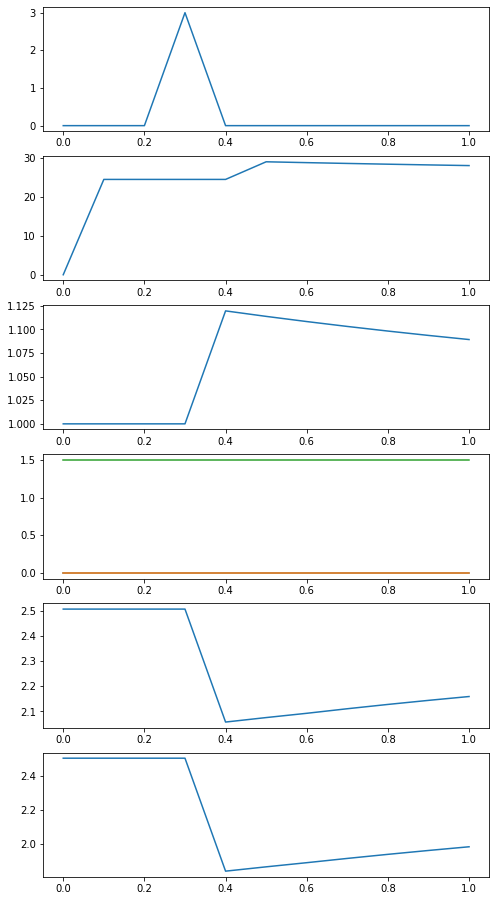

In [291]:
dur = 1.

a.params.duration = dur
a.params.ext_exc_current = 1.
target = a.getZeroTarget()
control1 = a.getZeroControl()

control1[0,0,3] += 3.
#control1[0,0,:] += np.sin(6.*np.arange(0,dur+a.params.dt,a.params.dt))

a.run(control=control1)

target[:,0,:] = a.state["rates_exc"][0,:]

fig, axes = plt.subplots(6, figsize=(8, 16))
axes[0].plot(a.t, control1[0,0,:])
axes[1].plot(a.t, a.state["rates_exc"][0,:])
axes[2].plot(a.t, a.state["mufe"][0,:])
axes[3].plot(a.t, a.state["seem"][0,:])
axes[3].plot(a.t, a.state["seev"][0,:])
axes[3].plot(a.t, a.state["sigmae_f"][0,:])
axes[4].plot(a.t, a.state["tau_exc"][0,:])

axes[5].plot(a.t, a.state["tau_exc"][0,:]/a.state["mufe"][0,:])

print(target)

In [292]:
max_cntrl = 10. * 5.
start_step = 100.
cost_params = [1.0, 3.0, 0.0]

init_state_vars = np.array( [a.params.rates_exc_init, a.params.mufe_init, a.params.seem_init, a.params.seev_init] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = a.getZeroControl()

max_it = 40

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

set cost params
RUN  0 , total integrated cost =  4.8800666602357685
RUN  1 , total integrated cost =  0.7616796552932287
RUN  2 , total integrated cost =  0.6910706979617752
RUN  3 , total integrated cost =  0.6591846469648285
RUN  4 , total integrated cost =  0.6569914061949237
RUN  5 , total integrated cost =  0.6550479041032083
RUN  6 , total integrated cost =  0.6550411927074413
RUN  7 , total integrated cost =  0.6550411331996066
RUN  8 , total integrated cost =  0.6550411326528438
RUN  9 , total integrated cost =  0.6550411326478199
RUN  10 , total integrated cost =  0.655041132647818
RUN  11 , total integrated cost =  0.6550411326478179
 max iteration reached, step size =  4.1213320123507144e-24
RUN  12 , total integrated cost =  0.6550411326478179
Control only changes marginally.
Improved over  12  iterations by  86.57720932410027  percent.
final grad =  [[[ 0.          0.26211929  0.27369567 -0.42132405 -1.87059349
    0.51626857  1.09709435  0.81170531  0.35631282  0.0653014

[[[0.         0.00619103 0.0062606  0.00633094 0.00536241 0.00441654
   0.00349254 0.00258962 0.00170704 0.00084407 0.        ]]]


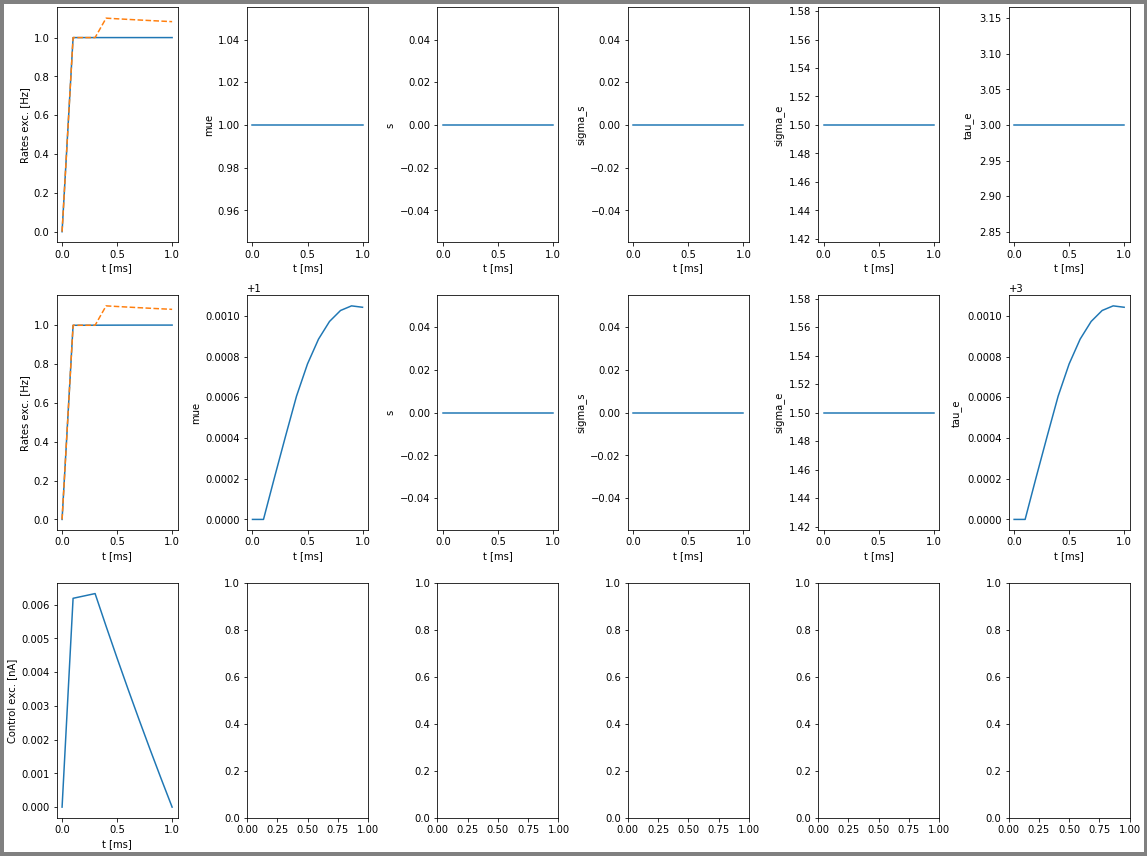

In [275]:
# 0.04889083173419056
print(A1_bestControlA)
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'simp')

In [ ]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 40

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  4.8800666602357685
RUN  1 , total integrated cost:  1.5989413477374248
RUN  2 , total integrated cost:  0.8504643280127757
RUN  3 , total integrated cost:  0.6151085344143622
RUN  4 , total integrated cost:  0.5459275429886187
RUN  5 , total integrated cost:  0.5266728231919044
RUN  6 , total integrated cost:  0.5206673670064207
RUN  7 , total integrated cost:  0.5176651101362301
RUN  8 , total integrated cost:  0.5156201053417961
RUN  9 , total integrated cost:  0.5142902065530023
RUN  10 , total integrated cost:  0.5135490353048261
RUN  11 , total integrated cost:  0.51320327457381
RUN  12 , total integrated cost:  0.5130685464230426
change helped, counter =  1
RUN  13 , total integrated cost:  0.513024476894153
change helped, counter =  1
RUN  14 , total integrated cost:  0.5130114891601896
change helped, counter =  1
change helped, counter =  1
change helped, counter =  1
RUN  15 , total integrated cost:  0.513007032067955
change help

[[[0.         0.00593561 0.00614251 0.00635893 0.0054356  0.00451951
   0.00360933 0.00270356 0.00180096 0.00090023 0.        ]]]


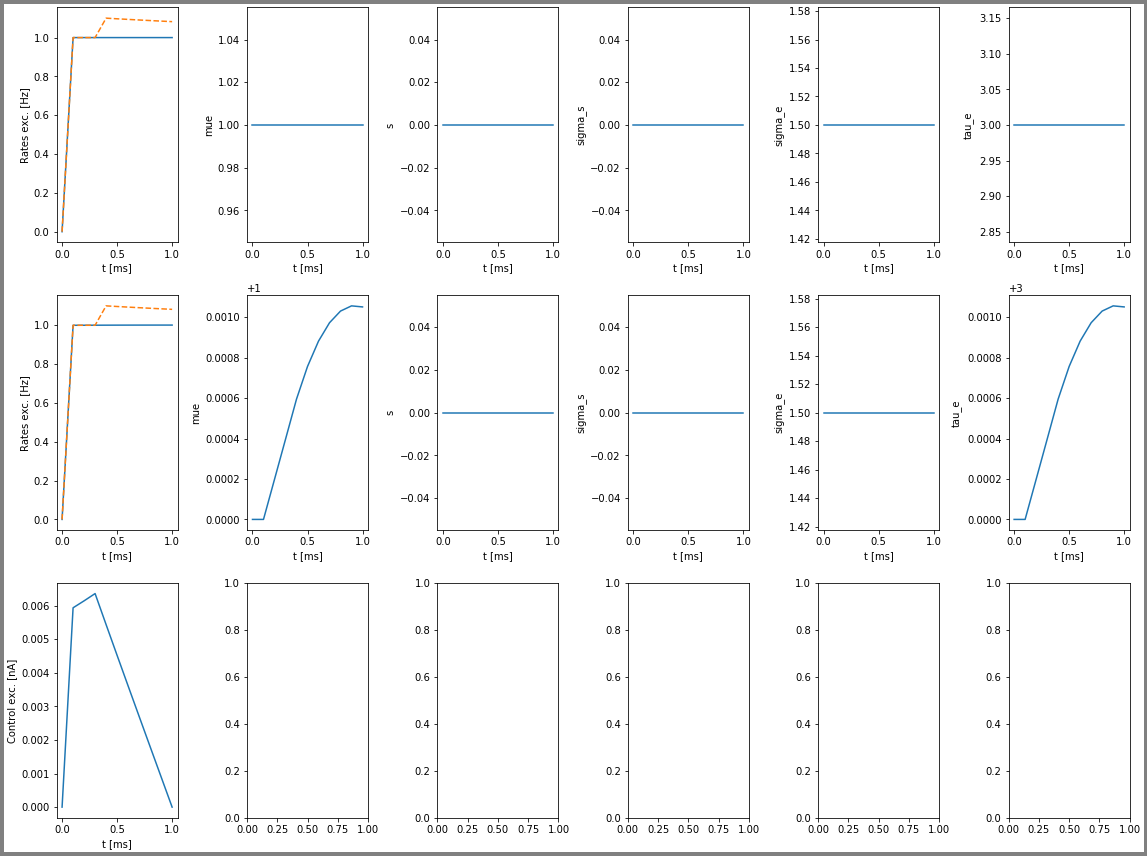

In [277]:
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

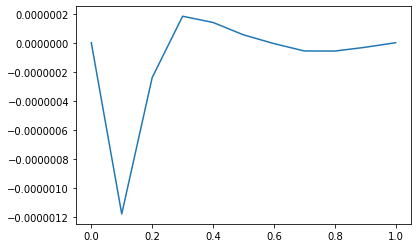

In [290]:
diff = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]

plt.plot(a.t, diff)
plt.show()

In [230]:
gradient_r = np.zeros(( len(a.params.Irange), len(a.params.sigmarange), 2 ))

sigma = a.params.sigmarange[0]
mu = a.params.Irange[0]

for sigma in range(len(a.params.sigmarange)-3):
    for mu in range(len(a.params.Irange)-1):
        res0 = jac_aln.der_mu(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_r)
        res1 = jac_aln.der_sigma(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        
def getindex(lower, upper, length, x_):
    return int( (x_ - lower) * (length-1) / (upper - lower) )

def get_value(lower, upper, length, index_):
    return lower + index_ * (upper - lower) / (length-1)

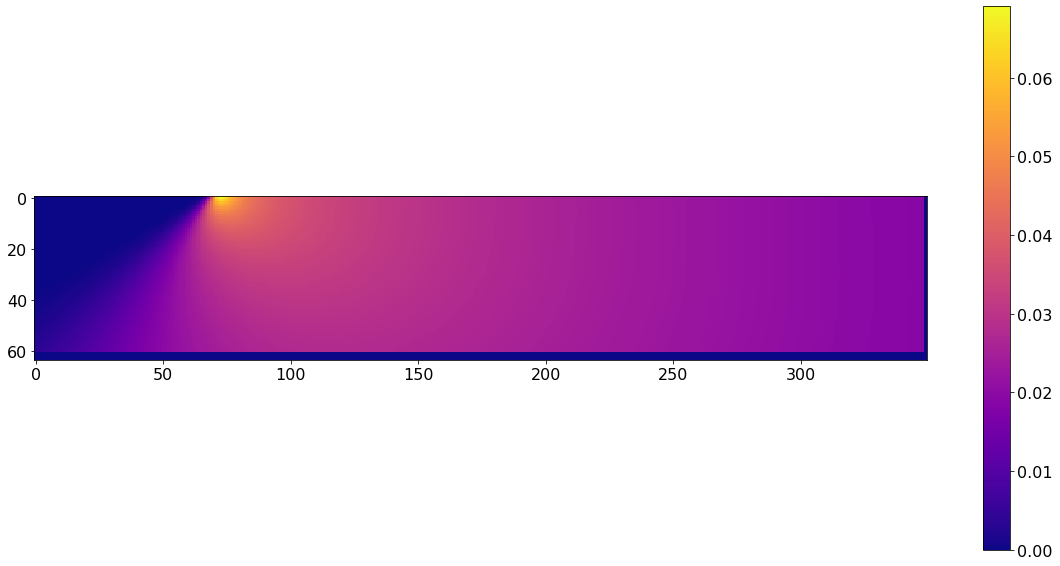

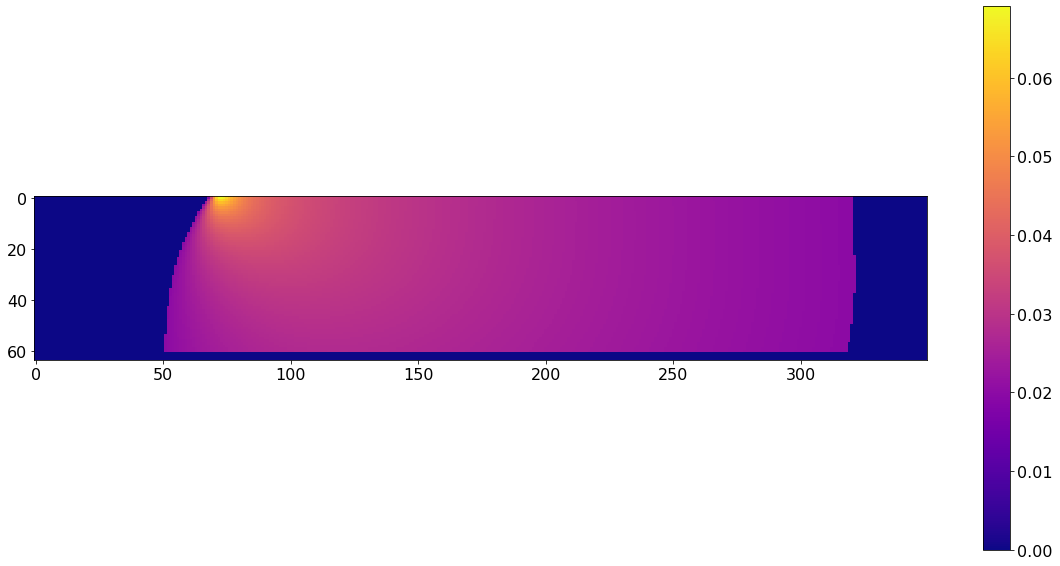

In [336]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar(orientation="horizontal")
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar(orientation="horizontal")
plt.show()

In [236]:
gradient_tau = np.zeros(( len(a.params.Irange), len(a.params.sigmarange), 2 ))

sigma = a.params.sigmarange[0]
mu = a.params.Irange[0]

for sigma in range(len(a.params.sigmarange)-3):
    for mu in range(len(a.params.Irange)-1):
        res0 = jac_aln.der_mu(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_tau_mu)
        res1 = jac_aln.der_sigma(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_tau_mu)
        gradient_tau[mu, sigma, 0] = res0
        gradient_tau[mu, sigma, 1] = res1

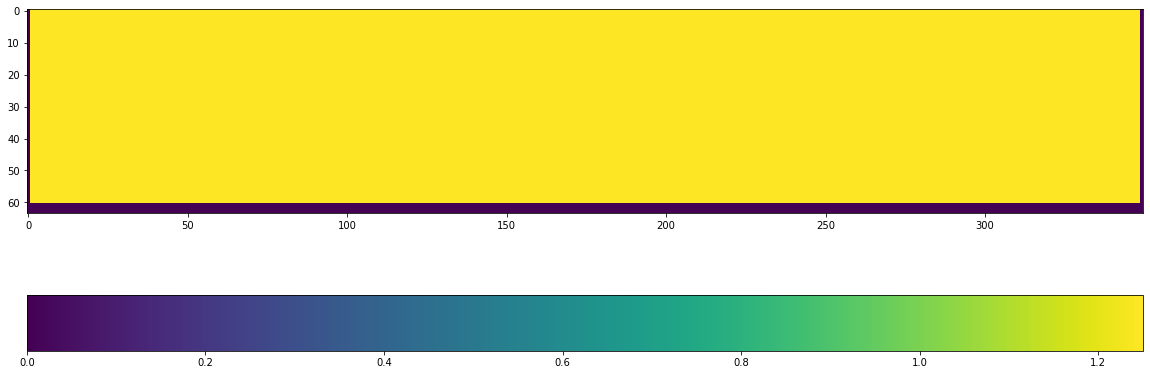

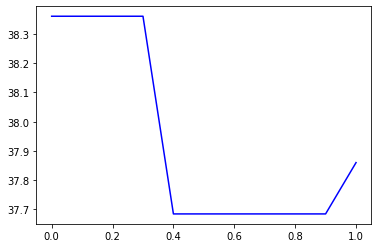

[38.36078583 38.36078583 38.36078583 38.36078583 37.68451449 37.68451449
 37.68451449 37.68451449 37.68451449 37.68451449 37.86004868]
[1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25]


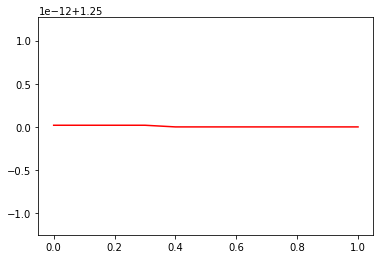

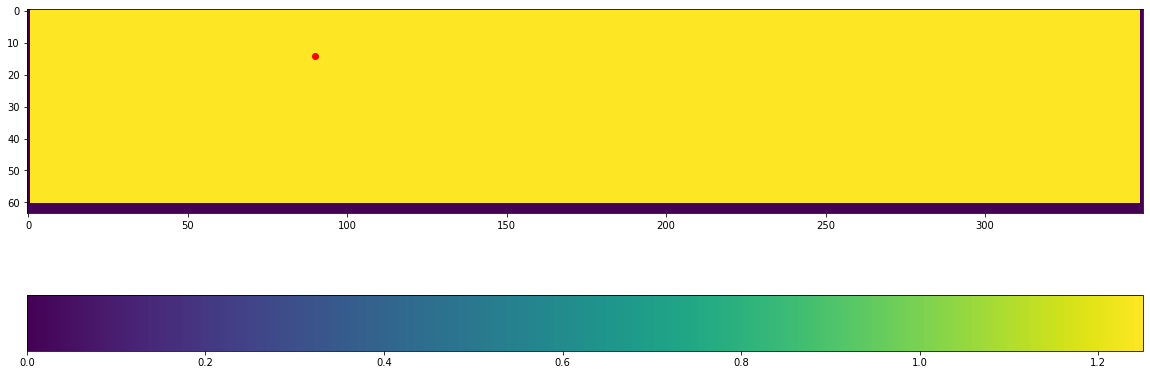

In [285]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_tau[:,:,0].T)
plt.colorbar(orientation="horizontal")
plt.show()

grad_r = np.zeros(( len(a.state["mufe"][0,:]) ))
grad_tau = np.zeros(( len(a.state["mufe"][0,:]) ))
for m in range(len(a.state["mufe"][0,:])):
    index_ = getindex(a.params.Irange[0], a.params.Irange[-1], len(a.params.Irange), a.state["mufe"][0,m])
    index_sigma_ = getindex(a.params.sigmarange[0], a.params.sigmarange[-1], len(a.params.sigmarange), 1.5)
    grad_r[m] = gradient_r[index_, index_sigma_, 0]
    grad_tau[m] = gradient_tau[index_, index_sigma_, 0]
    
plt.plot(a.t, grad_r*1e3, c="blue")
plt.show()
print(grad_r*1e3)
print(grad_tau)
plt.plot(a.t, grad_tau, c="red")
plt.show()


threshold = 0.02
large_g = gradient_tau.copy()
large_g[np.abs(large_g) < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.plot(index_, index_sigma_, "o", c="red")
plt.colorbar(orientation="horizontal")
plt.show()